Importamos Librerias 

In [1]:
import pandas as pd
import numpy as np
import io
from IPython.display import HTML
import base64
import random
import io
import base64

Simulación Base de datos con relación a la original

In [2]:
# ---------- 1. SUBIR ARCHIVO : ejemplo ----------
df_base = pd.read_excel("/Users/julianavalderrama/Documents/Complemetos Modelo/ejemplo.xlsx")

# ---------- 2. ESTADÍSTICAS POR MÉTRICA ----------
stats = df_base.groupby("METRICAS")["VALOR"].agg(["mean", "std"]).reset_index()

# Crear proyectos simulados con restricciones
nuevos_proyectos = 100
proyectos_simulados = []

for i in range(1, nuevos_proyectos + 1):
    proyecto = f"PROY_SIM_{str(i).zfill(3)}"
    ciudad = "CIUDAD_X"
    fecha = "2025-01-01"

    # FECHA ALEATORIA entre 2004 y 2025
    fecha = pd.to_datetime(random.choice(pd.date_range("2004-01-01", "2024-12-31", freq='MS'))).strftime('%Y-%m-%d')

    # Calcular variables simuladas
    m2_construidos = np.random.lognormal(np.log(stats.loc[stats["METRICAS"] == "M2_CONSTRUIDOS", "mean"].values[0] + 1), 0.3)
    m2_vendibles = np.random.uniform(0.5, 0.9) * m2_construidos
    m2_venta = np.random.lognormal(np.log(stats.loc[stats["METRICAS"] == "M2_VENTA", "mean"].values[0] + 1), 0.3)
    precio_m2 = np.random.uniform(18_000, 30_000)
    ventas = m2_venta * precio_m2

    costos = np.random.lognormal(np.log(stats.loc[stats["METRICAS"] == "COSTOS", "mean"].values[0] + 1), 0.3)
    lote = np.random.lognormal(np.log(stats.loc[stats["METRICAS"] == "LOTE", "mean"].values[0] + 1), 0.3)

    comisiones = ventas * np.random.uniform(0.02, 0.03)
    construct_fee = ventas * np.random.uniform(0.03, 0.045)
    mng_fee = max(ventas * np.random.uniform(0.01, 0.02), 100_000_000)
    sales_fee = max(ventas * np.random.uniform(0.01, 0.02), 600_000)
    monitor_fee = ventas * np.random.uniform(0.002, 0.008)
    desing_fee = max(ventas * np.random.uniform(0.01, 0.015), 30_000_000)
    estructuracion = max(ventas * np.random.uniform(0.001, 0.005), 400_000)
    indirectos = ventas * np.random.uniform(0.04, 0.08)

    valor_credito = np.random.uniform(0.4, 0.7) * (costos + lote)
    tasa = np.random.uniform(0.10, 0.14)
    unidades = np.random.randint(130, 550)
    cost_debt = tasa * valor_credito * (unidades / 100)
    tax = np.random.uniform(0.2, 0.3) * ventas

    # Diccionario de métricas
    variables = {
        "M2_CONSTRUIDOS": m2_construidos,
        "M2_VENDIBLES": m2_vendibles,
        "M2_VENTA": m2_venta,
        "VENTAS": ventas,
        "COSTOS": costos,
        "LOTE": lote,
        "COMISIONES": comisiones,
        "CONSTRUCT_FEE": construct_fee,
        "MNG_FEE": mng_fee,
        "SALES_FEE": sales_fee,
        "MONITOR_FEE": monitor_fee,
        "DESING_FEE": desing_fee,
        "ESTRUCTURACION": estructuracion,
        "INDIRECTOS": indirectos,
        "VALOR_CREDITO": valor_credito,
        "TASA": tasa,
        "COST_DEBT": cost_debt,
        "TAX": tax
    }

    for metrica, valor in variables.items():
        proyectos_simulados.append({
            "PROYECTO": proyecto,
            "CIUDAD": ciudad,
            "FECHA": fecha,
            "METRICAS": metrica,
            "VALOR": valor
        })

#  Convertir a DataFrame largo como el original
df_simulados_largo = pd.DataFrame(proyectos_simulados)

#  Concatenar con la base original
df_final = pd.concat([df_base, df_simulados_largo], ignore_index=True)

#  Exportar a Excel
df_final.to_excel("proyectos_simulados_restringidos.xlsx", index=False)
print("✅ Archivo exportado con el mismo formato largo que tu base original.")

#  Botón de descarga si estás en Jupyter
def crear_boton_descarga(df, nombre_archivo):
    towrite = io.BytesIO()
    df.to_excel(towrite, index=False, engine='openpyxl')
    towrite.seek(0)
    b64 = base64.b64encode(towrite.read()).decode()
    enlace = f'<a href="data:application/octet-stream;base64,{b64}" download="{nombre_archivo}">📥 Descargar archivo: {nombre_archivo}</a>'
    return HTML(enlace)

crear_boton_descarga(df_final, "proyectos_simulados_restringidos.xlsx")



✅ Archivo exportado con el mismo formato largo que tu base original.


Estandarizamos Fechas: Formato yy-mm-dd

In [3]:
# Diccionario de meses en español a número
meses = {
    'ENERO': '01', 'FEBRERO': '02', 'MARZO': '03', 'ABRIL': '04',
    'MAYO': '05', 'JUNIO': '06', 'JULIO': '07', 'AGOSTO': '08',
    'SEPTIEMBRE': '09', 'OCTUBRE': '10', 'NOVIEMBRE': '11', 'DICIEMBRE': '12'
}

# Función para convertir solo si la fecha no está ya en formato correcto
def convertir_fecha_seguro(fecha):
    if pd.isna(fecha):
        return None
    if isinstance(fecha, pd.Timestamp):
        return fecha  
    fecha_str = str(fecha).strip().upper()
    # Detectar si ya tiene formato YYYY-MM o YYYY-MM-DD
    if "-" in fecha_str and fecha_str[:4].isdigit():
        try:
            return pd.to_datetime(fecha_str)
        except:
            pass  # en caso de que esté mal escrita igual seguimos
    partes = fecha_str.split()
    if len(partes) == 2:
        mes, anio = partes
        mes_num = meses.get(mes)
        if mes_num:
            return pd.to_datetime(f"{anio}-{mes_num}-01", errors="coerce")
    return pd.NaT

# Aplicar transformación
df_final["FECHA"] = df_final["FECHA"].apply(convertir_fecha_seguro)

# Verificamos
print(df_final["FECHA"].head())


0   2024-10-01
1   2024-10-01
2   2024-10-01
3   2024-10-01
4   2024-10-01
Name: FECHA, dtype: datetime64[ns]


Se crea otro dataframe con la variable objetivo

In [4]:
# Pivot para tener una fila por proyecto
tabla = df_final.pivot_table(index="PROYECTO", columns="METRICAS", values="VALOR", aggfunc="first").reset_index()

# Calcular indicadores
tabla['GASTOS_INDIRECTOS'] = tabla[['CONSTRUCT_FEE', 'MNG_FEE', 'SALES_FEE',
                                    'MONITOR_FEE', 'DESING_FEE', 'ESTRUCTURACION',
                                    'INDIRECTOS']].sum(axis=1)

tabla['UT_BRUTA'] = tabla['VENTAS'] - tabla['COSTOS'] - tabla['LOTE']
tabla['UT_OPERATIVA'] = tabla['UT_BRUTA'] - tabla['GASTOS_INDIRECTOS']
tabla['EBITDA'] = tabla['UT_OPERATIVA'] - tabla['COST_DEBT']
tabla['UT_NETA'] = tabla['EBITDA'] - tabla['TAX']
tabla['MARGEN_NETO'] = tabla['UT_NETA'] / tabla['VENTAS']
tabla['ROI'] = tabla['UT_NETA'] / (tabla['COSTOS'] + tabla['LOTE'] + tabla['GASTOS_INDIRECTOS'])

# Crear DataFrame final con variable binaria
df_viabilidad = tabla[["PROYECTO", "ROI"]].copy()
df_viabilidad["VIABLE"] = (df_viabilidad["ROI"] > 0.4).astype(int)

# Exportar a Excel
df_viabilidad.to_excel("viabilidad_proyectos.xlsx", index=False)

print("✅ Archivo 'viabilidad_proyectos.xlsx' creado con éxito.")



✅ Archivo 'viabilidad_proyectos.xlsx' creado con éxito.


Se revisa frecuencia y distribución de la variable objetivo

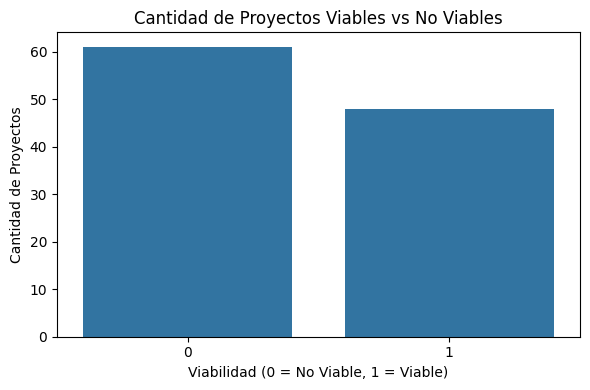

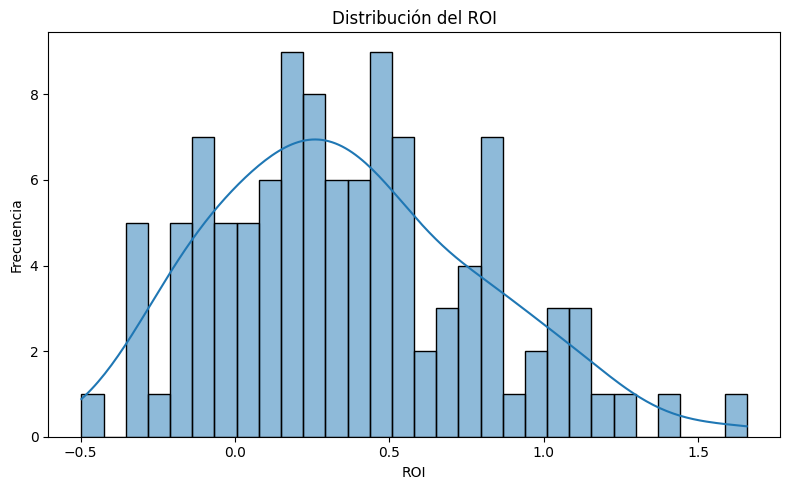

📊 El ROI fluctúa entre -0.50 y 1.66


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Conteo de proyectos viables vs no viables ---
conteo_viabilidad = df_viabilidad["VIABLE"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=conteo_viabilidad.index, y=conteo_viabilidad.values)
plt.title("Cantidad de Proyectos Viables vs No Viables")
plt.xlabel("Viabilidad (0 = No Viable, 1 = Viable)")
plt.ylabel("Cantidad de Proyectos")
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

# --- Distribución del ROI ---
plt.figure(figsize=(8, 5))
sns.histplot(df_viabilidad["ROI"], bins=30, kde=True)
plt.title("Distribución del ROI")
plt.xlabel("ROI")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# --- Rango de ROI ---
roi_min = df_viabilidad["ROI"].min()
roi_max = df_viabilidad["ROI"].max()
print(f"📊 El ROI fluctúa entre {roi_min:.2f} y {roi_max:.2f}")


Subimos función previamente hecha para testear modelos on 10k-fold

In [6]:
from sklearn.metrics import roc_auc_score

def evaluate_model_with_kfold2(model, X, y, n_splits=10, random_state=42):
    from sklearn.model_selection import KFold
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_accs, test_accs = [], []
    train_auc_scores, test_auc_scores = [], []

    all_y_true = []
    all_y_pred = []
    all_y_scores = []
    conf_matrices = []

    for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)

        # Test predictions
        y_pred = model.predict(X_test)
        y_proba_test = model.predict_proba(X_test)[:, 1]

        # Train predictions
        y_pred_train = model.predict(X_train)
        y_proba_train = model.predict_proba(X_train)[:, 1]

        # Metrics
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred)
        auc_train = roc_auc_score(y_train, y_proba_train)
        auc_test = roc_auc_score(y_test, y_proba_test)
        cm = confusion_matrix(y_test, y_pred)

        # Store results
        train_accs.append(acc_train)
        test_accs.append(acc_test)
        train_auc_scores.append(auc_train)
        test_auc_scores.append(auc_test)
        conf_matrices.append(cm)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_scores.extend(y_proba_test)

        print(f'Fold {fold}')
        print(f'Train Accuracy: {acc_train:.4f} | AUC: {auc_train:.4f}')
        print(f' Test  Accuracy: {acc_test:.4f} | AUC: {auc_test:.4f}')
        print(f'Confusion Matrix:\n{cm}')
        print('-' * 60)

    # Visualización de la matriz total
    total_cm = np.sum(conf_matrices, axis=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title('Total Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Resultados promedio
    print(f'\n Avg Train Accuracy: {np.mean(train_accs):.4f}, AUC: {np.mean(train_auc_scores):.4f}')
    print(f' Avg Test  Accuracy: {np.mean(test_accs):.4f}, AUC: {np.mean(test_auc_scores):.4f}')

    # Reporte de clasificación general
    print('\n Final Classification Report (All Folds Combined):')
    print(classification_report(all_y_true, all_y_pred))

    return {
        "train_accuracies": train_accs,
        "test_accuracies": test_accs,
        "train_aucs": train_auc_scores,
        "test_aucs": test_auc_scores,
        "conf_matrices": conf_matrices
    }



Se añaden macros al modelo: (se suben los archivos complementarios de inflación, PIB, tasa desempleo)

In [9]:
# ---------------------------
# 1. Estandarizar archivos originales
# ---------------------------

inflacion_df = pd.read_excel("/Users/julianavalderrama/Documents/Complemetos Modelo/inflacion_basica.xlsx")
desempleo_df = pd.read_excel("/Users/julianavalderrama/Documents/Complemetos Modelo/Tasa_desempleo.xlsx")
pib_df = pd.read_excel("/Users/julianavalderrama/Documents/Complemetos Modelo/PIB.xlsx")

# === Inflación mensual ===
inflacion_df.columns = ["FECHA", "IPC_NIVEL", "INFLACION"]
inflacion_df = inflacion_df.dropna(subset=["FECHA"])
inflacion_df["FECHA"] = pd.to_datetime(inflacion_df["FECHA"], format="%Y-%m-%d")
inflacion_df = inflacion_df[["FECHA", "INFLACION"]]

# === Desempleo mensual ===
desempleo_df.columns = ["FECHA", "DESEMPLEO"]
desempleo_df["FECHA"] = pd.to_datetime(desempleo_df["FECHA"], errors="coerce", format="%Y/%m/%d")
desempleo_df = desempleo_df.dropna(subset=["FECHA"])
desempleo_df = desempleo_df[["FECHA", "DESEMPLEO"]]

# === PIB sectorial trimestral ===
pib_df = pib_df.dropna(axis=1, how='all')              # quitar columnas vacías
pib_df.columns = [f"col_{i}" for i in range(pib_df.shape[1])]  # evitar nombres duplicados
pib_df = pib_df[pd.to_datetime(pib_df["col_0"], errors="coerce",format="%Y-%m-%d" ).notna()]  # filtrar filas con fecha válida
pib_df["FECHA"] = pd.to_datetime(pib_df["col_0"], errors="coerce", format="%Y-%m-%d")
pib_df = pib_df[["FECHA", "col_3"]]                    # cambia col_3 por otra si es necesario
pib_df.columns = ["FECHA", "PIB_SECTORIAL"]
pib_df["TRIMESTRE"] = pib_df["FECHA"].dt.to_period("Q").dt.start_time

# ---------------------------
# 2. Combinar todas las series macro en un solo DataFrame
# ---------------------------

# Merge inflación y desempleo
macro_df = pd.merge(inflacion_df, desempleo_df, on="FECHA", how="outer")

# Merge PIB sectorial con forward fill mensual
macro_df = pd.merge(macro_df, pib_df, on="FECHA", how="outer")
macro_df.sort_values("FECHA", inplace=True)
macro_df.ffill(inplace=True)

# Crear la columna PERIODO como el mes anterior a FECHA
macro_df["PERIODO"] = (macro_df["FECHA"] - pd.DateOffset(months=1)).dt.to_period("M").dt.to_timestamp()
macro_df.dropna(subset=["INFLACION", "DESEMPLEO", "PIB_SECTORIAL"], inplace=True)

# 5. Exportar a Excel
macro_df.to_excel("macro_df_consolidado.xlsx", index=False)
print("✅ Archivo guardado como 'macro_df_consolidado.xlsx'")


✅ Archivo guardado como 'macro_df_consolidado.xlsx'


/var/folders/w1/2gzxgq0s7g1dz2172t9vrtcw0000gn/T/ipykernel_25783/2579700945.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  macro_df.ffill(inplace=True)


Cambiamos el formato de la base de datos para que el modelo se pueda entrenar (formato ancho)

In [10]:
#  Extraer la fecha de cada proyecto 
fechas_proyectos = df_final[["PROYECTO", "FECHA"]].drop_duplicates()

# Transformar df_X de largo a ancho
df_X_wide = df_final.pivot_table(index="PROYECTO", columns="METRICAS", values="VALOR", aggfunc='first').reset_index()

# 3. Agregar la fecha al formato ancho
df_X_wide = df_X_wide.merge(fechas_proyectos, on="PROYECTO", how="left")
df_X_wide

,PROYECTO,COMISIONES,CONSTRUCT_FEE,COSTOS,COST_DEBT,DESING_FEE,ESTRUCTURACION,INDIRECTOS,LOTE,M2_CONSTRUIDOS,M2_VENDIBLES,M2_VENTA,MNG_FEE,MONITOR_FEE,SALES_FEE,TASA,TAX,VALOR_CREDITO,VENTAS,FECHA
0,AQUA,4.334730e+09,2.034032e+09,5.085080e+10,8.000000e+09,3.396390e+07,4.583808e+07,1.011437e+10,1.444910e+10,32037.000000,18161.000000,7.000000e+06,2.167365e+09,1.444910e+09,7.224550e+08,0.120000,3.410404e+08,3.330147e+09,1.444910e+11,2024-06-01
1,CRUCERO,5.144537e+09,3.223138e+09,7.674138e+10,1.029231e+10,6.384370e+08,1.714846e+09,1.156343e+10,2.315042e+10,32320.980000,18335.440000,9.352629e+06,5.144537e+09,9.208965e+08,1.714846e+09,0.120000,3.272169e+09,6.139310e+10,1.714846e+11,2024-04-01
2,FLOR_DE_ORO,2.317346e+09,1.628071e+09,4.070179e+10,6.253103e+09,4.070179e+08,1.084356e+09,6.632546e+09,3.476019e+09,27080.740000,17144.080000,4.505629e+06,2.317346e+09,4.884214e+08,7.724486e+08,0.140000,1.473352e+09,2.442107e+10,7.724486e+10,2024-02-01
3,LUXE92,1.645308e+09,9.919800e+08,3.306600e+10,3.219445e+09,3.306600e+08,8.555603e+08,6.001891e+09,6.000000e+09,10020.000000,4537.780000,1.450320e+07,1.316247e+09,3.306600e+08,3.290617e+08,0.150000,1.255163e+09,1.983960e+10,6.581233e+10,2024-10-01
4,PALERMO,3.660000e+09,1.568000e+09,3.920000e+10,4.000000e+09,8.540000e+08,4.026000e+08,8.540000e+09,9.760000e+09,31820.000000,28000.000000,4.300000e+06,1.830000e+09,1.220000e+09,6.100000e+08,0.140000,1.666619e+08,1.631952e+09,1.220000e+11,2025-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,PROY_SIM_097,6.236220e+09,9.696248e+09,7.299400e+10,2.072949e+10,3.217596e+09,2.766699e+08,9.704614e+09,2.114814e+10,25011.950811,16058.607594,7.476143e+06,4.307495e+09,8.052548e+08,3.040281e+09,0.139321,5.529415e+10,3.805366e+10,2.230583e+11,2007-04-01
105,PROY_SIM_098,3.751101e+09,6.186960e+09,5.675140e+10,1.308277e+10,2.597476e+09,7.584262e+08,1.111473e+10,1.291770e+10,30855.190987,25760.743733,6.986494e+06,1.941738e+09,1.059516e+09,3.471490e+09,0.128539,5.298030e+10,3.869984e+10,1.840709e+11,2008-06-01
106,PROY_SIM_099,3.165159e+09,4.479571e+09,5.279422e+10,5.613819e+09,1.646288e+09,3.629968e+08,6.188723e+09,2.111640e+10,29593.488665,23161.902659,5.139248e+06,2.337091e+09,2.825279e+08,1.899450e+09,0.121211,2.850140e+10,3.508670e+10,1.172844e+11,2010-03-01
107,PROY_SIM_100,5.955536e+09,1.004918e+10,5.934626e+10,7.895342e+09,3.059761e+09,3.918129e+08,1.590947e+10,7.803540e+09,31237.612278,24867.130829,1.075370e+07,3.322234e+09,1.007061e+09,4.324929e+09,0.139183,5.302979e+10,3.223084e+10,2.278830e+11,2007-05-01


Unimos todo en un solo dataframe: variables explicativas, fecha, macros rezagadas un periodo, ROI, variable binaria 

In [11]:
# Crear columna PERIODO (mes anterior a FECHA del proyecto)
df_X_wide["PERIODO"] = (
    pd.to_datetime(df_X_wide["FECHA"])
    - pd.DateOffset(months=1)
).dt.to_period("M").dt.to_timestamp()

# Limpiar macro_df: asegurar un solo valor por PERIODO
macro_limpio = (
    macro_df[["PERIODO", "INFLACION", "DESEMPLEO", "PIB_SECTORIAL"]]
    .drop_duplicates(subset="PERIODO")
    .groupby("PERIODO", as_index=False)
    .agg("first")
)

# Eliminar versiones anteriores de columnas macro si existen en df_X_wide
df_X_wide = df_X_wide.drop(columns=["INFLACION", "DESEMPLEO", "PIB_SECTORIAL"], errors="ignore")

# Hacer merge con macro_df limpio
df_X_wide = df_X_wide.merge(macro_limpio, on="PERIODO", how="left")

# Eliminar columna auxiliar PERIODO
df_X_wide.drop(columns="PERIODO", inplace=True)

# Eliminar filas con valores faltantes
df_X_wide = df_X_wide.dropna()

# Agregar la variable objetivo desde df_viabilidad
df_full = df_X_wide.merge(df_viabilidad, on="PROYECTO", how="left").dropna(subset=["VIABLE"])

# Dividir en X (features) e y (target)
X = df_full.drop(columns=["PROYECTO", "VIABLE", "ROI", "FECHA"])
y = df_full["VIABLE"]

# (Opcional) Exportar a Excel final
df_full.to_excel("df_X_wide_con_macro_y_viable.xlsx", index=False)
print("✅ Archivo exportado como df_X_wide_con_macro_y_viable.xlsx")


✅ Archivo exportado como df_X_wide_con_macro_y_viable.xlsx


In [12]:
df_full

,PROYECTO,COMISIONES,CONSTRUCT_FEE,COSTOS,COST_DEBT,DESING_FEE,ESTRUCTURACION,INDIRECTOS,LOTE,M2_CONSTRUIDOS,...,TASA,TAX,VALOR_CREDITO,VENTAS,FECHA,INFLACION,DESEMPLEO,PIB_SECTORIAL,ROI,VIABLE
0,AQUA,4.334730e+09,2.034032e+09,5.085080e+10,8.000000e+09,3.396390e+07,4.583808e+07,1.011437e+10,1.444910e+10,32037.000000,...,0.120000,3.410404e+08,3.330147e+09,1.444910e+11,2024-06-01,7.097915,10.31,4.837450,0.663147,1
1,CRUCERO,5.144537e+09,3.223138e+09,7.674138e+10,1.029231e+10,6.384370e+08,1.714846e+09,1.156343e+10,2.315042e+10,32320.980000,...,0.120000,3.272169e+09,6.139310e+10,1.714846e+11,2024-04-01,7.327764,11.29,1.821298,0.265264,0
2,FLOR_DE_ORO,2.317346e+09,1.628071e+09,4.070179e+10,6.253103e+09,4.070179e+08,1.084356e+09,6.632546e+09,3.476019e+09,27080.740000,...,0.140000,1.473352e+09,2.442107e+10,7.724486e+10,2024-02-01,8.065541,12.66,4.398812,0.208847,0
3,LUXE92,1.645308e+09,9.919800e+08,3.306600e+10,3.219445e+09,3.306600e+08,8.555603e+08,6.001891e+09,6.000000e+09,10020.000000,...,0.150000,1.255163e+09,1.983960e+10,6.581233e+10,2024-10-01,5.908552,9.13,1.829529,0.246143,0
4,PARADISE,3.317009e+09,2.843966e+09,7.109914e+10,8.124150e+09,8.531897e+08,1.724845e+09,7.473582e+09,8.432000e+09,26502.630000,...,0.110000,2.533984e+09,4.621444e+10,1.326804e+11,2023-10-01,9.905650,9.25,0.107055,0.256431,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,PROY_SIM_097,6.236220e+09,9.696248e+09,7.299400e+10,2.072949e+10,3.217596e+09,2.766699e+08,9.704614e+09,2.114814e+10,25011.950811,...,0.139321,5.529415e+10,3.805366e+10,2.230583e+11,2007-04-01,5.930038,12.03,2.407391,0.174490,0
100,PROY_SIM_098,3.751101e+09,6.186960e+09,5.675140e+10,1.308277e+10,2.597476e+09,7.584262e+08,1.111473e+10,1.291770e+10,30855.190987,...,0.128539,5.298030e+10,3.869984e+10,1.840709e+11,2008-06-01,5.270584,10.81,15.673372,0.219096,0
101,PROY_SIM_099,3.165159e+09,4.479571e+09,5.279422e+10,5.613819e+09,1.646288e+09,3.629968e+08,6.188723e+09,2.111640e+10,29593.488665,...,0.121211,2.850140e+10,3.508670e+10,1.172844e+11,2010-03-01,3.003281,12.69,0.519208,-0.087129,0
102,PROY_SIM_100,5.955536e+09,1.004918e+10,5.934626e+10,7.895342e+09,3.059761e+09,3.918129e+08,1.590947e+10,7.803540e+09,31237.612278,...,0.139183,5.302979e+10,3.223084e+10,2.278830e+11,2007-05-01,6.189685,10.81,2.407391,0.586837,1


Entrenamos el modelo con la función previamente cargada

🌲 Random Forest
Fold 1
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.9091 | AUC: 1.0000
Confusion Matrix:
[[3 0]
 [1 7]]
------------------------------------------------------------
Fold 2
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.7273 | AUC: 0.8929
Confusion Matrix:
[[6 1]
 [2 2]]
------------------------------------------------------------
Fold 3
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.8182 | AUC: 0.9667
Confusion Matrix:
[[5 0]
 [2 4]]
------------------------------------------------------------
Fold 4
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.8182 | AUC: 0.8571
Confusion Matrix:
[[6 1]
 [1 3]]
------------------------------------------------------------
Fold 5
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 1.0000 | AUC: 1.0000
Confusion Matrix:
[[5 0]
 [0 5]]
------------------------------------------------------------
Fold 6
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.9000 | AUC: 1.0000
Confusion Matrix:
[[6 

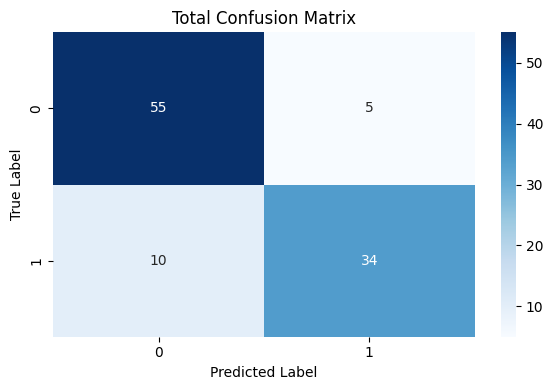


 Avg Train Accuracy: 1.0000, AUC: 1.0000
 Avg Test  Accuracy: 0.8573, AUC: 0.9574

 Final Classification Report (All Folds Combined):
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        60
           1       0.87      0.77      0.82        44

    accuracy                           0.86       104
   macro avg       0.86      0.84      0.85       104
weighted avg       0.86      0.86      0.85       104


🚀 Gradient Boosting
Fold 1
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 1.0000 | AUC: 1.0000
Confusion Matrix:
[[3 0]
 [0 8]]
------------------------------------------------------------
Fold 2
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.8182 | AUC: 0.8929
Confusion Matrix:
[[7 0]
 [2 2]]
------------------------------------------------------------
Fold 3
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 0.9091 | AUC: 1.0000
Confusion Matrix:
[[5 0]
 [1 5]]
--------------------------------------------------

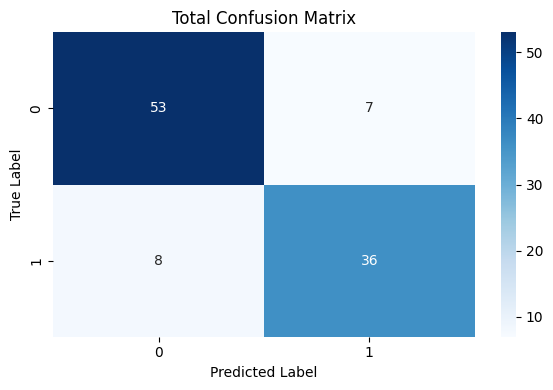


 Avg Train Accuracy: 1.0000, AUC: 1.0000
 Avg Test  Accuracy: 0.8536, AUC: 0.9388

 Final Classification Report (All Folds Combined):
              precision    recall  f1-score   support

           0       0.87      0.88      0.88        60
           1       0.84      0.82      0.83        44

    accuracy                           0.86       104
   macro avg       0.85      0.85      0.85       104
weighted avg       0.86      0.86      0.86       104


📈 Logistic Regression
Fold 1
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 1.0000 | AUC: 1.0000
Confusion Matrix:
[[3 0]
 [0 8]]
------------------------------------------------------------
Fold 2
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 1.0000 | AUC: 1.0000
Confusion Matrix:
[[7 0]
 [0 4]]
------------------------------------------------------------
Fold 3
Train Accuracy: 1.0000 | AUC: 1.0000
 Test  Accuracy: 1.0000 | AUC: 1.0000
Confusion Matrix:
[[5 0]
 [0 6]]
------------------------------------------------

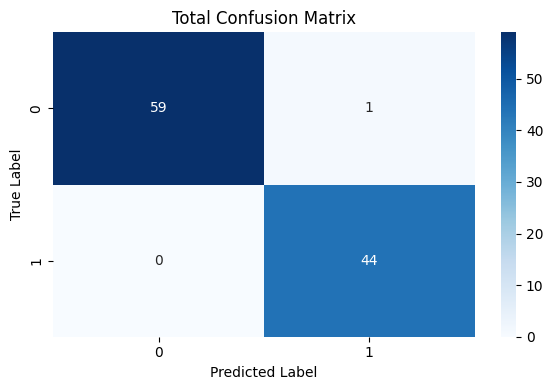


 Avg Train Accuracy: 1.0000, AUC: 1.0000
 Avg Test  Accuracy: 0.9909, AUC: 1.0000

 Final Classification Report (All Folds Combined):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       0.98      1.00      0.99        44

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



In [13]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Instanciar modelos
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
logit = LogisticRegression(solver="liblinear", random_state=42)

# Evaluar cada modelo con tu función de k-fold
print("🌲 Random Forest")
resultados_rf = evaluate_model_with_kfold2(rf, X, y)

print("\n🚀 Gradient Boosting")
resultados_gb = evaluate_model_with_kfold2(gb, X, y)

print("\n📈 Logistic Regression")
resultados_logit = evaluate_model_with_kfold2(logit, X, y)

Guardamos el modelo entrenado para añadirlo a la página interactiva

In [14]:
# Entrenar el modelo final completo (fuera de kfold)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib

# Escalador
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Usa X limpio y sin fecha

# Entrenar modelo final
modelo_rf_final = RandomForestClassifier(random_state=42)
modelo_rf_final.fit(X_scaled, y)

# Guardar modelo y scaler
joblib.dump(modelo_rf_final, "modelo_rf.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Se intenta generar una base de datos en el formato largo que acepta la página (pero no se pudo garcias al orden de las variables)

In [15]:

# Eliminar las columnas 'VIABILIDAD' y 'ROI'
df_full_t = df_full.drop(columns=["VIABLE", "ROI"])

# Convertir el DataFrame a formato largo
df_largo = df_full_t.melt(id_vars=["PROYECTO"], var_name="FECHA", value_name="VALUE")

# Mostrar el resultado
print(df_largo.head())

# base para el modelo. Guardar en archivo 
df_largo.to_excel("base_ejemplo_sim.xlsx", index=False)
print("✅ Archivo generado y guardado como 'base_ejemplo_sim.xlsx'")

      PROYECTO       FECHA              VALUE
0         AQUA  COMISIONES       4334730000.0
1      CRUCERO  COMISIONES  5144536984.476056
2  FLOR_DE_ORO  COMISIONES       2317345860.0
3       LUXE92  COMISIONES       1645308272.4
4     PARADISE  COMISIONES  3317008925.139332
✅ Archivo generado y guardado como 'base_ejemplo_sim.xlsx'


(Gráfico adicional para la elavoración del paper )

In [16]:
import pandas as pd

# Definir los datos
data = {
    "Variable": [
        "Área construida (m²)",
        "Área vendible (m²)",
        "Precio de venta por m²",
        "Costo del lote",
        "Costo total de construcción",
        "Gastos indirectos",
        "Ingresos por ventas",
        "Utilidad neta",
        "ROI",
        "Tasa de interés de referencia",
        "Inflación básica (base 2018)",
        "PIB del sector construcción",
        "Tasa de desempleo",
        "Tasa de ocupación",
        "Fecha de inicio del proyecto"
    ],
    "Tipo": [
        "Continua", "Continua", "Continua", "Continua", "Continua",
        "Porcentual", "Derivada", "Derivada", "Derivada (Target)",
        "Macroeconómica", "Macroeconómica", "Macroeconómica", "Macroeconómica",
        "Macroeconómica", "Temporal categórica"
    ],
    "Distribución simulada": [
        "Lognormal", "Proporción de área construida", "Lognormal", "Lognormal", "Lognormal",
        "Uniforme acotada", "Área vendible × Precio por m²", "Ingresos – Costos totales", 
        "Utilidad neta / Costo total", "Real (mensual)", "Real (mensual)", 
        "Real (trimestral)", "Real (mensual)", "Real (mensual)", "Uniforme entre 2004–2024"
    ],
    "Fuente / Restricción aplicada": [
        "Basada en promedio y desviación de proyectos reales",
        "Uniforme entre 0.5 y 0.9",
        "Rangos estimados por el constructor",
        "Promedio histórico ajustado a inflación",
        "Proporcional a área construida",
        "5% a 15% de las ventas (según experto)",
        "Calculada",
        "Calculada",
        "Calculada, umbral de 40% para clasificación (VIABLE)",
        "Banco de la República (2004–2024)",
        "Banco de la República",
        "DANE (base 2015)",
        "DANE",
        "DANE",
        "Asignación aleatoria con rezago para variables macro"
    ]
}

# Crear el DataFrame
tabla_variables = pd.DataFrame(data)

# Mostrar el DataFrame
tabla_variables



,Variable,Tipo,Distribución simulada,Fuente / Restricción aplicada
0,Área construida (m²),Continua,Lognormal,Basada en promedio y desviación de proyectos r...
1,Área vendible (m²),Continua,Proporción de área construida,Uniforme entre 0.5 y 0.9
2,Precio de venta por m²,Continua,Lognormal,Rangos estimados por el constructor
3,Costo del lote,Continua,Lognormal,Promedio histórico ajustado a inflación
4,Costo total de construcción,Continua,Lognormal,Proporcional a área construida
5,Gastos indirectos,Porcentual,Uniforme acotada,5% a 15% de las ventas (según experto)
6,Ingresos por ventas,Derivada,Área vendible × Precio por m²,Calculada
7,Utilidad neta,Derivada,Ingresos – Costos totales,Calculada
8,ROI,Derivada (Target),Utilidad neta / Costo total,"Calculada, umbral de 40% para clasificación (V..."
9,Tasa de interés de referencia,Macroeconómica,Real (mensual),Banco de la República (2004–2024)
